In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()
image_names = list(uploaded.keys())
print("Uploaded:", image_names)

Saving 1.png to 1.png
Saving 2.png to 2.png
Saving 3.png to 3.png
Saving 4.png to 4.png
Saving 5.png to 5.png
Saving 6.png to 6.png
Saving 7.png to 7.png
Saving 8.png to 8.png
Saving 9.png to 9.png
Uploaded: ['1.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png']


Fungsi bantu: grayscale, statistik, diagnosis

In [ ]:
# STEP 2 — Helper functions

def load_rgb(path):
    """Load an image and return it in RGB order (OpenCV loads BGR)."""
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

def to_grayscale(rgb):
    """RGB -> grayscale using the luminosity formula (BT.601)."""
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def image_stats(gray):
    g = gray.astype(np.float64)
    return {"mean": g.mean(), "std": g.std(), "min": g.min(), "max": g.max(),
            "p1": np.percentile(g, 1), "p99": np.percentile(g, 99)}

def lighting_uniformity(gray, grid=3):
    """Range of block means across a grid x grid split; higher = more uneven."""
    h, w = gray.shape
    means = [gray[i*h//grid:(i+1)*h//grid, j*w//grid:(j+1)*w//grid].mean()
             for i in range(grid) for j in range(grid)]
    return max(means) - min(means)

def noise_floor(gray, block=16):
    """Noise estimate = std of the flattest bright (paper) patches."""
    h, w = gray.shape
    stds = [gray[i:i+block, j:j+block].std()
            for i in range(0, h-block, block) for j in range(0, w-block, block)
            if gray[i:i+block, j:j+block].mean() > 120]
    stds = np.sort(stds)
    return float(np.median(stds[:max(20, len(stds)//10)]))

def color_cast(rgb):
    means = [rgb[:, :, c].mean() for c in range(3)]
    return max(means) - min(means)

def diagnose(rgb, gray):
    """Heuristic problem detection. Thresholds are tunable."""
    s = image_stats(gray)
    p = []
    if s["mean"] < 100:                  p.append("too dark")
    if s["p99"] < 190:                   p.append("highlights not reaching white")
    if s["mean"] > 240 and s["p1"] > 60: p.append("too bright / overexposed")
    if s["std"] < 40:                    p.append("low contrast")
    if lighting_uniformity(gray) > 25:   p.append("uneven lighting")
    if noise_floor(gray) > 5:            p.append("visible noise")
    if color_cast(rgb) > 25:             p.append("color cast")
    return s, (p if p else ["no major issue"])

Grayscale + histogram + diagnosis untuk semua citra

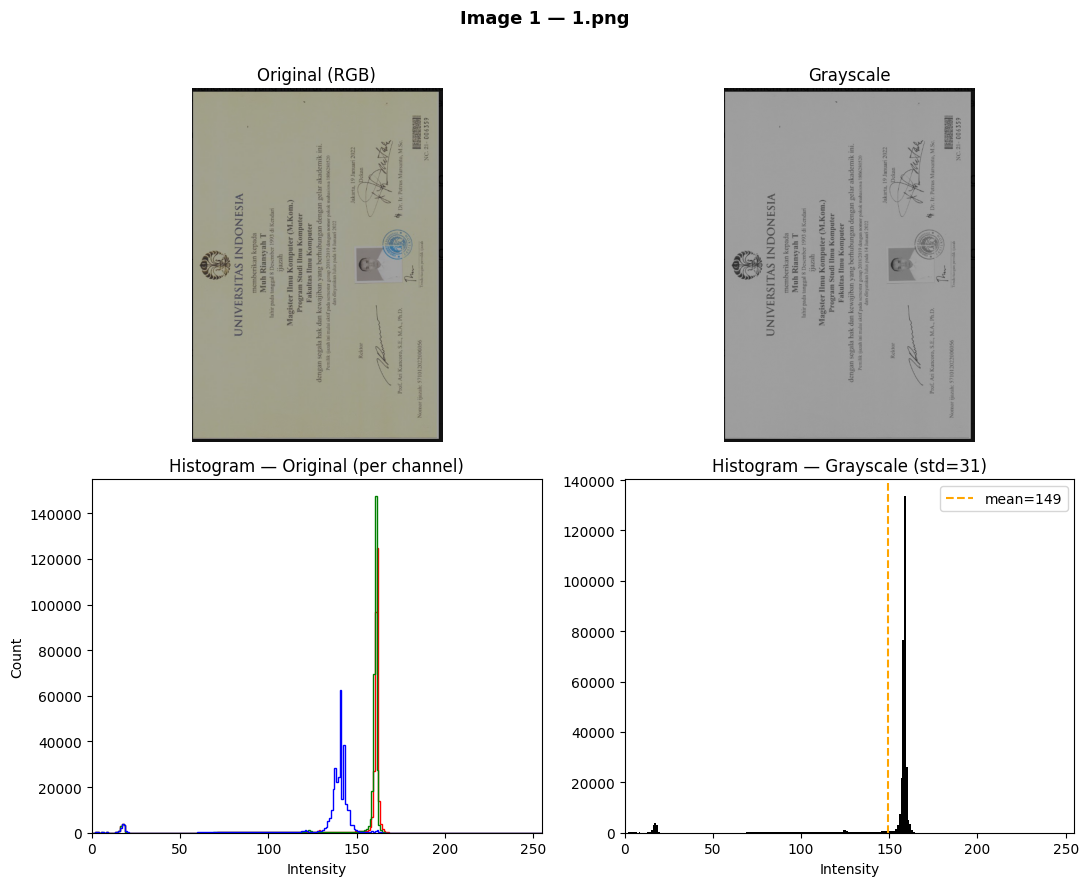

Image 1: mean=149.3 std=30.5 max=168 p99=162 -> highlights not reaching white, low contrast



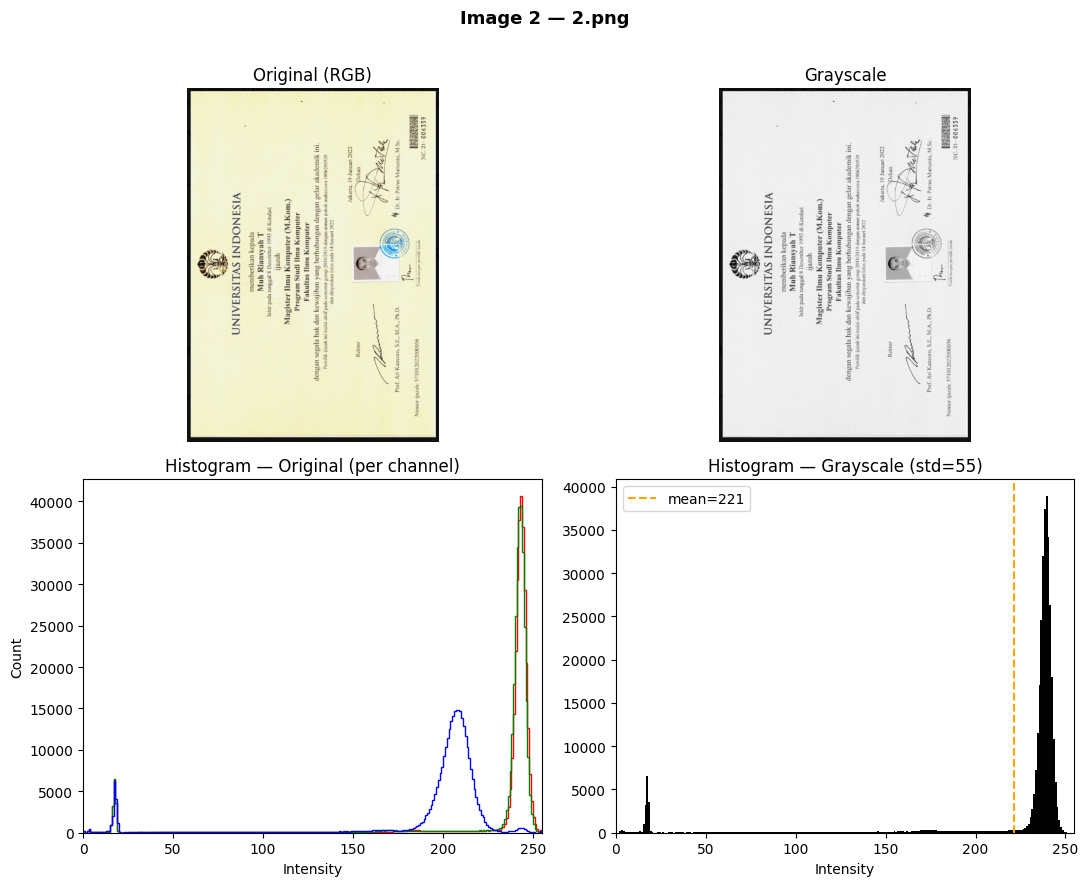

Image 2: mean=221.3 std=54.5 max=253 p99=246 -> color cast



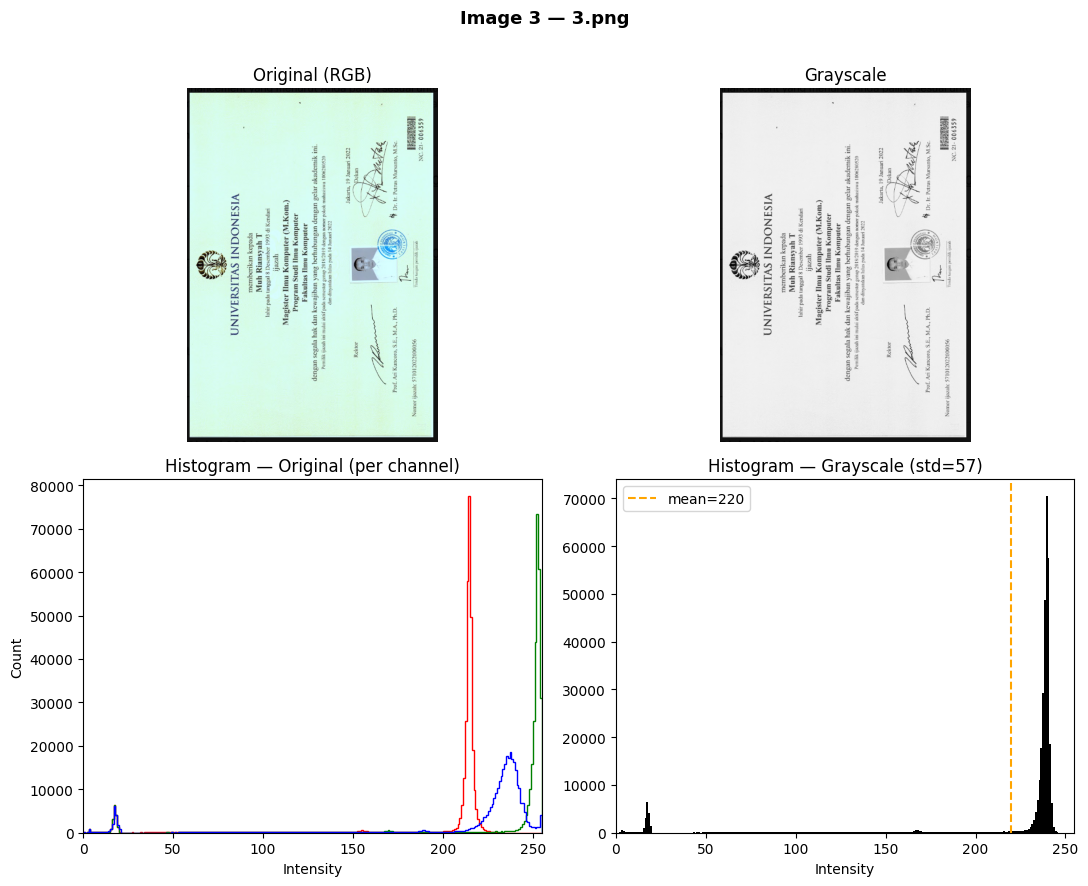

Image 3: mean=219.5 std=57.2 max=249 p99=243 -> color cast



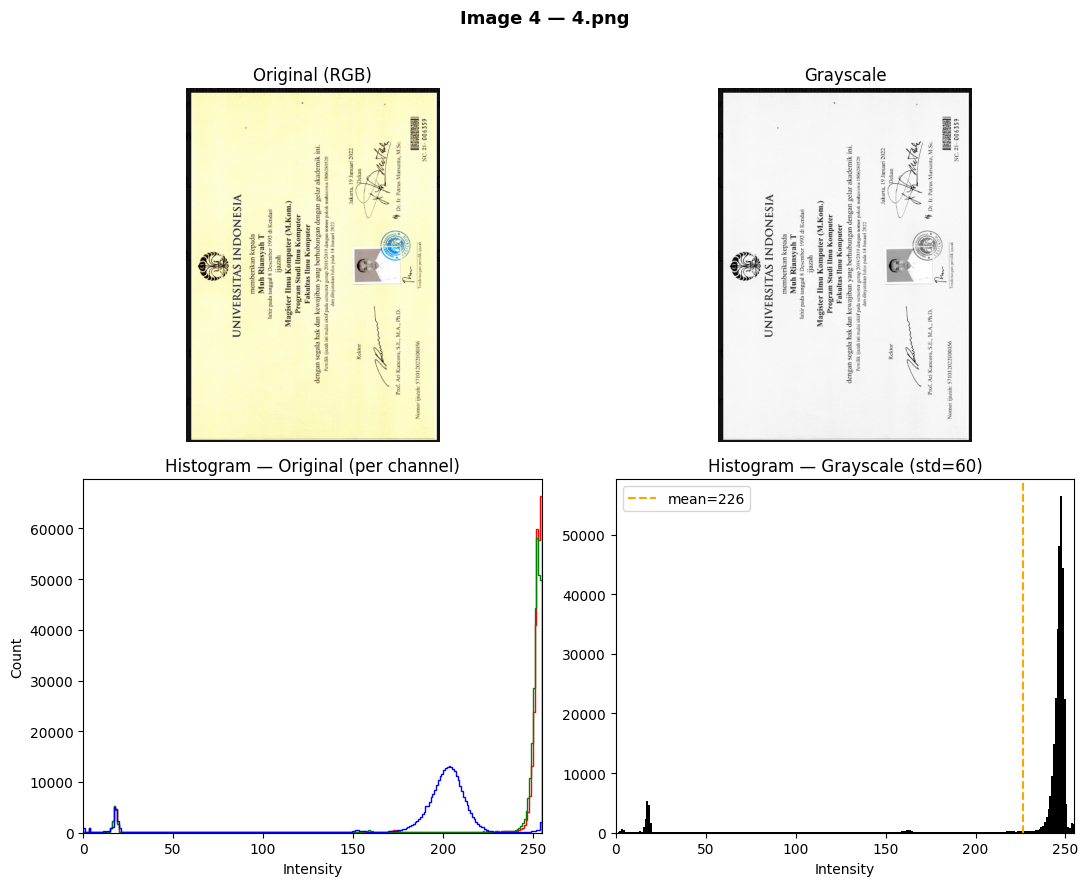

Image 4: mean=226.3 std=59.8 max=255 p99=253 -> uneven lighting, color cast



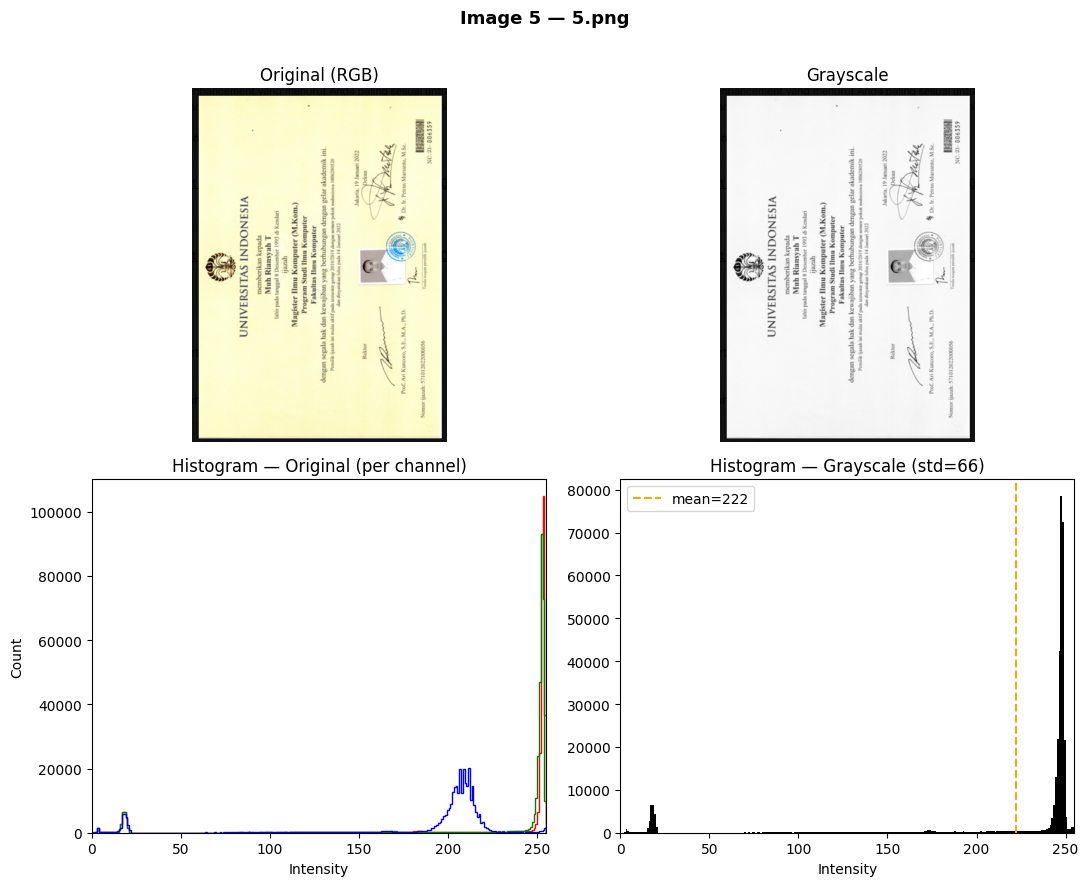

Image 5: mean=222.2 std=65.5 max=255 p99=253 -> uneven lighting, color cast



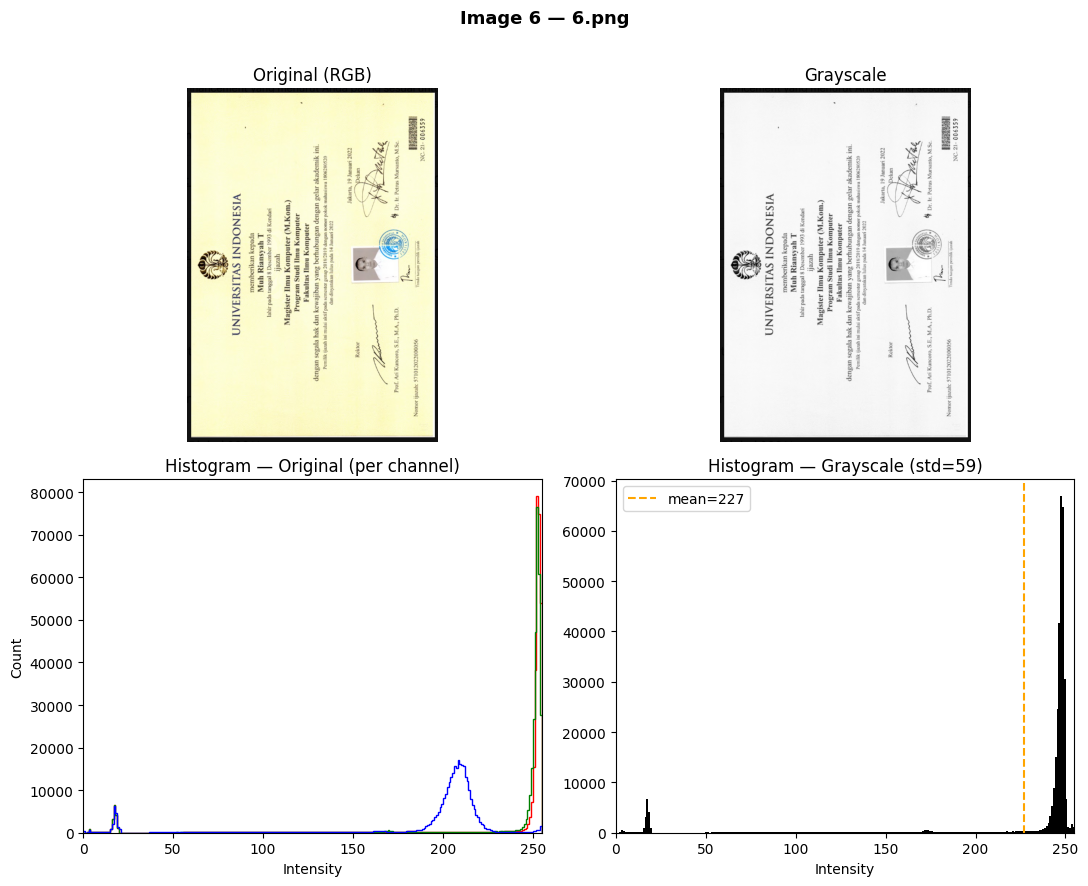

Image 6: mean=227.0 std=59.1 max=255 p99=253 -> color cast



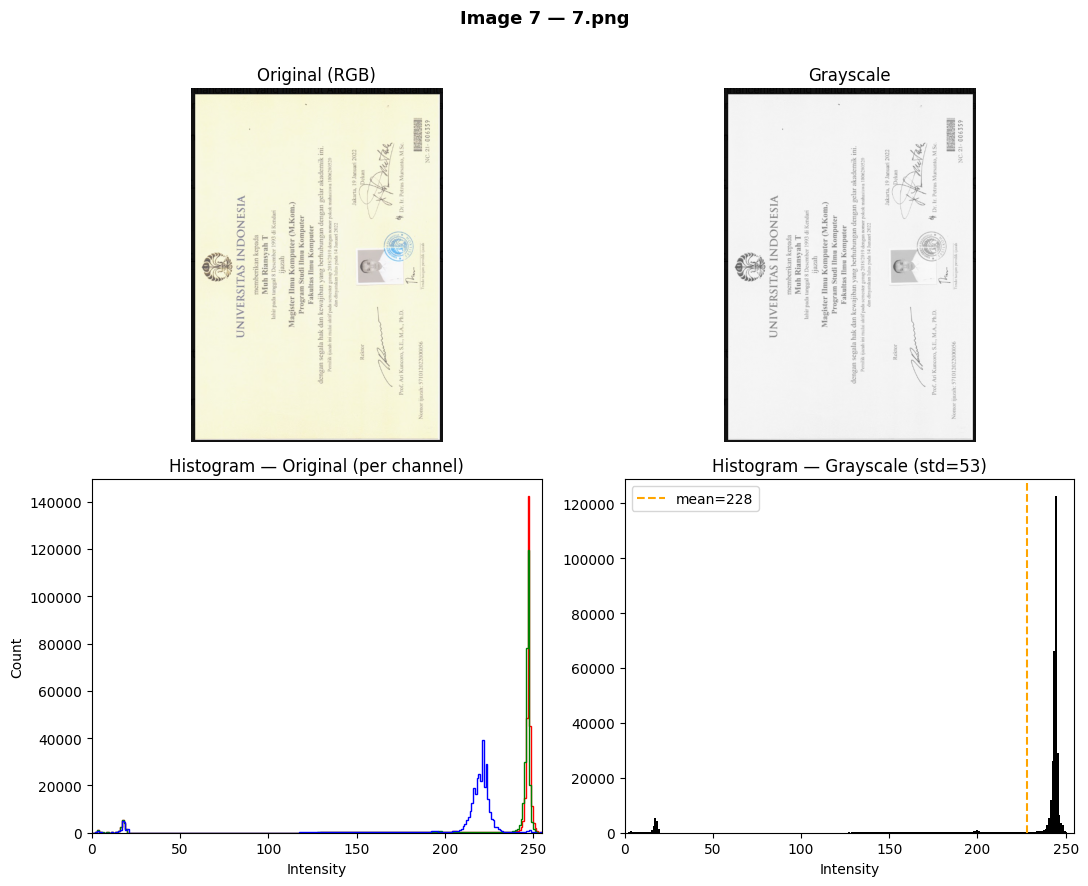

Image 7: mean=227.9 std=53.0 max=253 p99=249 -> no major issue



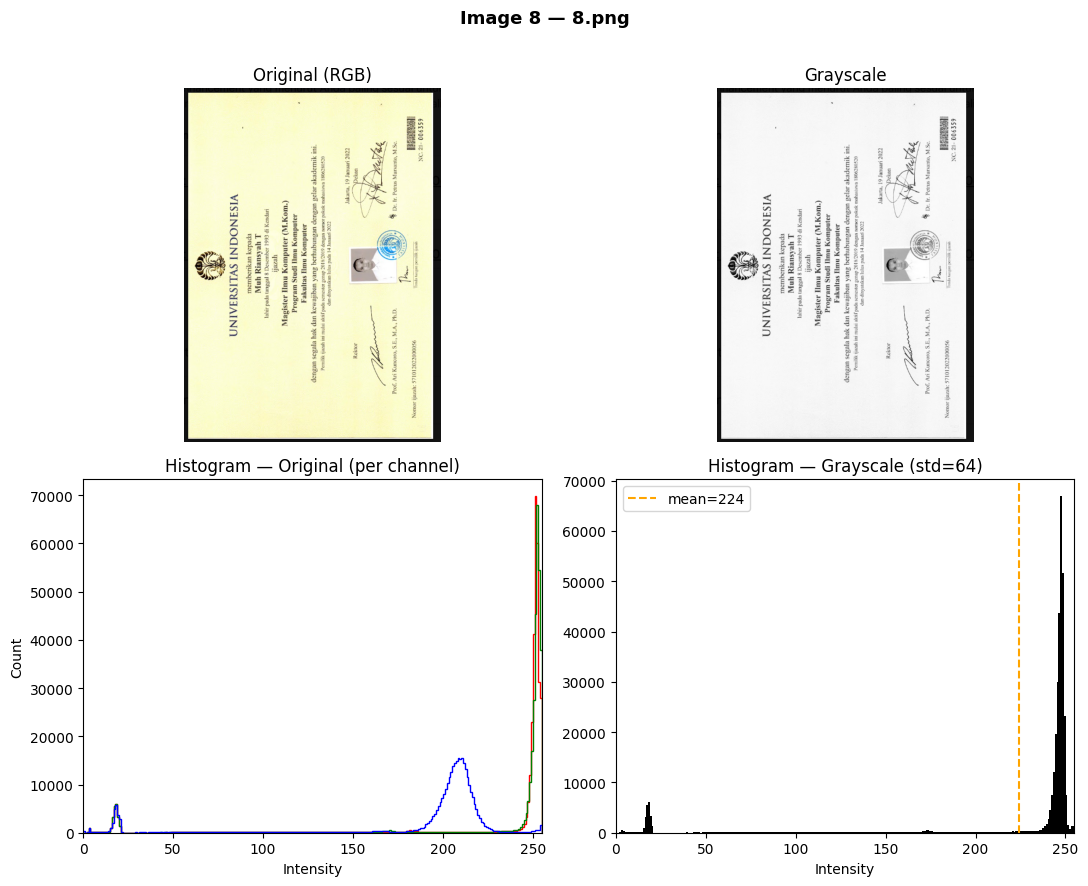

Image 8: mean=223.9 std=63.8 max=255 p99=253 -> uneven lighting, color cast



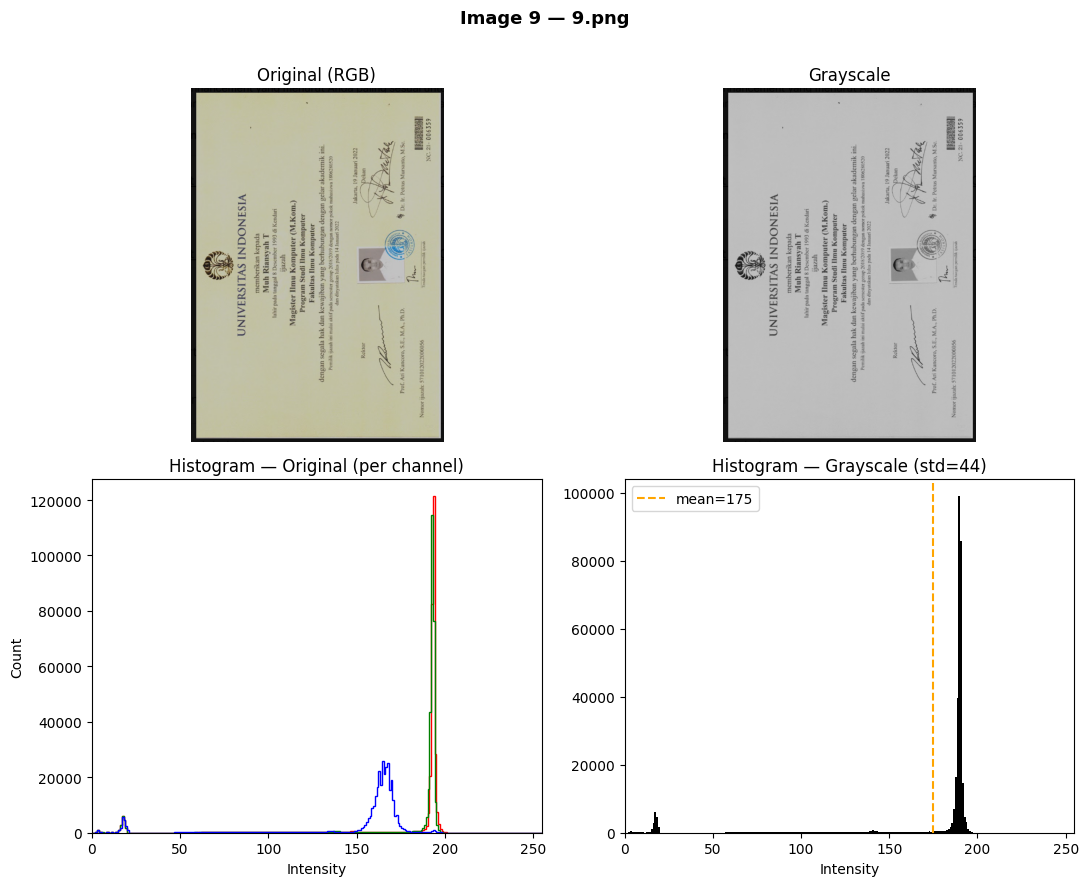

Image 9: mean=175.1 std=43.7 max=201 p99=194 -> color cast



In [ ]:
# Grayscale + histograms + diagnosis for every image
for idx, name in enumerate(image_names, start=1):
    rgb, gray = load_rgb(name), to_grayscale(load_rgb(name))
    stats, problems = diagnose(rgb, gray)

    fig, ax = plt.subplots(2, 2, figsize=(11, 9))
    fig.suptitle(f"Image {idx} — {name}", fontsize=13, fontweight="bold")
    ax[0,0].imshow(rgb); ax[0,0].set_title("Original (RGB)"); ax[0,0].axis("off")
    ax[0,1].imshow(gray, cmap="gray", vmin=0, vmax=255); ax[0,1].set_title("Grayscale"); ax[0,1].axis("off")
    for c, col in zip(range(3), ["red","green","blue"]):
        ax[1,0].hist(rgb[:,:,c].ravel(), bins=256, range=(0,255), color=col, histtype="step", lw=1.2)
    ax[1,0].set_title("Histogram — Original (per channel)"); ax[1,0].set_xlim(0,255)
    ax[1,0].set_xlabel("Intensity"); ax[1,0].set_ylabel("Count")
    ax[1,1].hist(gray.ravel(), bins=256, range=(0,255), color="black")
    ax[1,1].axvline(stats["mean"], color="orange", ls="--", label=f"mean={stats['mean']:.0f}")
    ax[1,1].set_title(f"Histogram — Grayscale (std={stats['std']:.0f})")
    ax[1,1].set_xlim(0,255); ax[1,1].set_xlabel("Intensity"); ax[1,1].legend()
    plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

    print(f"Image {idx}: mean={stats['mean']:.1f} std={stats['std']:.1f} "
          f"max={stats['max']:.0f} p99={stats['p99']:.0f} -> {', '.join(problems)}\n")

METODE ANHANCEMENT

In [ ]:
# STEP 4 — Enhancement methods
def contrast_stretch(gray, low_p=1, high_p=99):
    lo, hi = np.percentile(gray, [low_p, high_p])
    out = (gray.astype(np.float64) - lo) * 255.0 / max(hi - lo, 1e-6)
    return np.clip(out, 0, 255).astype(np.uint8)

def hist_equalize(gray):
    return cv2.equalizeHist(gray)                      # global HE

def clahe(gray, clip=2.0, grid=8):
    return cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid)).apply(gray)

def gamma_correct(gray, gamma):                        # <1 brighten, >1 darken
    lut = np.array([((i/255.0)**gamma)*255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(gray, lut)

Terapkan metode & bandingkan before/after

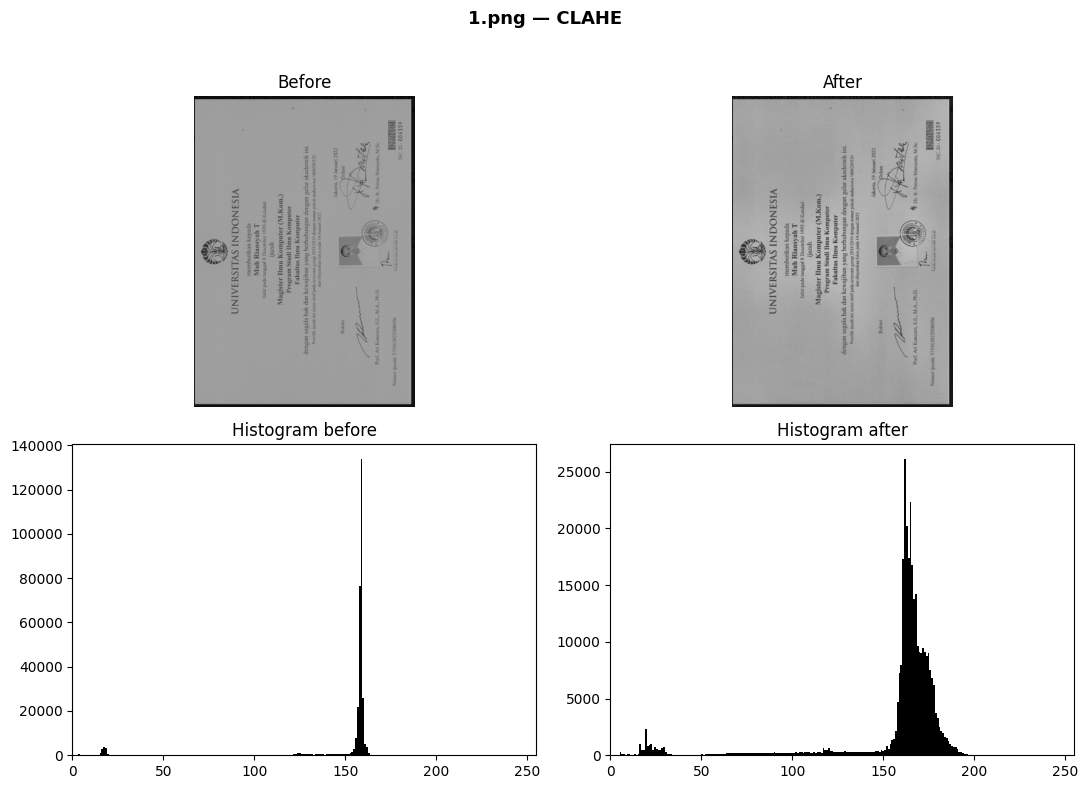

In [ ]:
# STEP 5 — Apply the recommended method and compare
def show_before_after(gray, enhanced, title):
    fig, ax = plt.subplots(2, 2, figsize=(11, 8))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    ax[0,0].imshow(gray, cmap="gray", vmin=0, vmax=255); ax[0,0].set_title("Before"); ax[0,0].axis("off")
    ax[0,1].imshow(enhanced, cmap="gray", vmin=0, vmax=255); ax[0,1].set_title("After"); ax[0,1].axis("off")
    ax[1,0].hist(gray.ravel(), bins=256, range=(0,255), color="black"); ax[1,0].set_title("Histogram before"); ax[1,0].set_xlim(0,255)
    ax[1,1].hist(enhanced.ravel(), bins=256, range=(0,255), color="black"); ax[1,1].set_title("Histogram after"); ax[1,1].set_xlim(0,255)
    plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

name = image_names[0]                      # change index to pick an image
gray = to_grayscale(load_rgb(name))
enhanced = clahe(gray, clip=2.0, grid=8)
# for very dark images (1 & 9) try: enhanced = contrast_stretch(gamma_correct(gray, 0.7))
show_before_after(gray, enhanced, f"{name} — CLAHE")